In [1]:
# %% 셀 1: Setup — 데이터 로드 + Dataset (train notebook 구조와 동일)
import os, json, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import polars as pl
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from torch.utils.data import Dataset, DataLoader

POS_DIR = "./data/8_telop_position"
STT_DIR = "./data/4_stt_results"
EMB_PATH = "./data/8_text_embeddings.pt"
CKPT_PATH = "./model/8_layout_2_boxset/best.pt"

GRID_W = 80
GRID_H = 80
EVAL_PER_CHANNEL = 5
SEED = 42
NUM_WORKERS = 32
FPS = 10
MAX_FRAMES = 2000
MAX_ACTIVE_PER_FRAME = 150
MAX_TEXT_LEN = 200
SCALAR_DIM = 9
TIME_DIM = 3
BATCH_SIZE = 8
NUM_WORKERS_DL = 8

text2emb = torch.load(EMB_PATH, weights_only=True)
EMB_DIM = next(iter(text2emb.values())).shape[0]
ZERO_EMB = torch.zeros(EMB_DIM)
print(f"✅ 임베딩: {len(text2emb):,}개  dim={EMB_DIM}")


def stt_frames_to_segments(df_stt):
    rows = df_stt.sort("frame_num").to_dicts()
    segments = []
    cur_text = None
    cur_start_frame = None
    prev_frame = None
    for r in rows:
        t = r["stt_text"]
        f = int(r["frame_num"])
        if t != cur_text:
            if cur_text is not None and cur_text != "":
                segments.append({
                    "start": cur_start_frame / FPS,
                    "end": (prev_frame + 1) / FPS,
                    "text": cur_text.strip(),
                })
            cur_text = t
            cur_start_frame = f
        prev_frame = f
    if cur_text is not None and cur_text != "":
        segments.append({
            "start": cur_start_frame / FPS,
            "end": (prev_frame + 1) / FPS,
            "text": cur_text.strip(),
        })
    return segments


def load_one(args):
    channel, path = args
    with open(path, "r") as f:
        data = json.load(f)
    instances = data.get("instances", [])
    duration = data.get("duration", 0.1)
    if instances:
        duration = max(duration, max(inst["end_sec"] for inst in instances))
    video_name = data.get("video", "")
    file_id = os.path.basename(path)[:-5]
    inst_list = []
    for inst in instances:
        gx = int(np.clip(round(inst["grid_x"]), 0, GRID_W - 1))
        gy = int(np.clip(round(inst["grid_y"]), 0, GRID_H - 1))
        gw = int(np.clip(round(inst["grid_w"]), 1, GRID_W))
        gh = int(np.clip(round(inst["grid_h"]), 1, GRID_H))
        inst_list.append({
            "text": inst["text"],
            "text_len": len(inst["text"]),
            "start": inst["start_sec"],
            "end": inst["end_sec"],
            "x": gx, "y": gy, "w": gw, "h": gh,
        })
    stt_path = os.path.join(STT_DIR, channel, file_id + ".parquet")
    stt_segments = []
    if os.path.exists(stt_path):
        try:
            df_stt = pl.read_parquet(stt_path, glob=False)
            stt_segments = stt_frames_to_segments(df_stt)
        except:
            pass
    return {
        "channel": channel,
        "video_name": video_name,
        "file_id": file_id,
        "instances": inst_list,
        "stt_segments": stt_segments,
        "duration": duration,
    }


json_paths = []
for channel in sorted(os.listdir(POS_DIR)):
    ch_dir = os.path.join(POS_DIR, channel)
    if not os.path.isdir(ch_dir):
        continue
    for fname in sorted(os.listdir(ch_dir)):
        if fname.endswith(".json"):
            json_paths.append((channel, os.path.join(ch_dir, fname)))

samples = []
channel_set = set()
with ProcessPoolExecutor(max_workers=NUM_WORKERS) as pool:
    futures = {pool.submit(load_one, args): args for args in json_paths}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="로드"):
        result = fut.result()
        channel_set.add(result["channel"])
        samples.append(result)

channels = sorted(channel_set)
channel2id = {ch: i for i, ch in enumerate(channels)}

# eval split (train과 동일 시드)
rng = random.Random(SEED)
by_channel = {}
for s in samples:
    by_channel.setdefault(s["channel"], []).append(s)

eval_samples = []
for ch, ch_samples in by_channel.items():
    ch_samples.sort(key=lambda s: s["file_id"])
    rng.shuffle(ch_samples)
    n_eval = min(EVAL_PER_CHANNEL, len(ch_samples))
    eval_samples.extend(ch_samples[:n_eval])

eval_samples = [s for s in eval_samples if len(s["instances"]) > 0]

# train과 동일: channel 67개 sub-sample (seed 42)
rng_ch = random.Random(42)
sampled_channels = rng_ch.sample(channels, 67)
sampled_set = set(sampled_channels)
eval_samples = [s for s in eval_samples if s["channel"] in sampled_set]
channels = sampled_channels
channel2id = {ch: i for i, ch in enumerate(channels)}

print(f"✅ 채널 sub-sample: {len(channels)}  eval: {len(eval_samples):,}")


class BoxSetSegmentDataset(Dataset):
    def __init__(self, samples, channel2id, text2emb):
        self.samples = [s for s in samples if len(s["instances"]) > 0]
        self.channel2id = channel2id
        self.text2emb = text2emb

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        channel_id = self.channel2id[s["channel"]]
        instances = s["instances"]
        duration = max(s["duration"], 0.1)
        n_frames = max(1, min(int(duration * FPS) + 1, MAX_FRAMES))
        n_inst = len(instances)

        inst_starts = np.array([inst["start"] for inst in instances])
        inst_ends   = np.array([inst["end"]   for inst in instances])
        inst_tlens  = np.array([inst["text_len"] for inst in instances])
        inst_cx = np.array([inst["x"] for inst in instances])
        inst_cy = np.array([inst["y"] for inst in instances])
        inst_w  = np.array([inst["w"] for inst in instances])
        inst_h  = np.array([inst["h"] for inst in instances])

        inst_x0 = np.maximum(0, inst_cx - inst_w // 2)
        inst_y0 = np.maximum(0, inst_cy - inst_h // 2)
        inst_x1 = np.minimum(GRID_W, inst_x0 + inst_w)
        inst_y1 = np.minimum(GRID_H, inst_y0 + inst_h)

        channel_emb = F.normalize(self.text2emb.get(s["channel"], ZERO_EMB), dim=-1)
        video_emb   = F.normalize(self.text2emb.get(s["video_name"], ZERO_EMB), dim=-1)
        inst_embs   = torch.stack([
            self.text2emb.get(inst["text"], ZERO_EMB) for inst in instances])
        inst_embs = F.normalize(inst_embs, dim=-1)

        inst_diff_ch  = inst_embs - channel_emb.unsqueeze(0)
        inst_diff_vid = inst_embs - video_emb.unsqueeze(0)
        inst_diff_stt = torch.zeros(n_inst, EMB_DIM)

        ch_sims  = F.cosine_similarity(inst_embs, channel_emb.unsqueeze(0), dim=-1).numpy()
        vid_sims = F.cosine_similarity(inst_embs, video_emb.unsqueeze(0), dim=-1).numpy()

        stt_sims = np.zeros(n_inst, dtype=np.float32)
        has_stts = np.zeros(n_inst, dtype=np.float32)
        stt_segments = s["stt_segments"]
        if len(stt_segments) > 0:
            stt_starts = np.array([seg["start"] for seg in stt_segments])
            stt_ends   = np.array([seg["end"]   for seg in stt_segments])
            stt_embs_raw = torch.stack([
                self.text2emb.get(seg["text"], ZERO_EMB) for seg in stt_segments])
            stt_embs = F.normalize(stt_embs_raw, dim=-1)
            for i in range(n_inst):
                mid = (inst_starts[i] + inst_ends[i]) / 2
                stt_active = (stt_starts <= mid) & (stt_ends > mid)
                stt_active_idx = np.where(stt_active)[0]
                if len(stt_active_idx) > 0:
                    inst_diff_stt[i] = inst_embs[i] - stt_embs[stt_active_idx[0]]
                    stt_sims[i] = F.cosine_similarity(
                        inst_embs[i].unsqueeze(0), stt_embs[stt_active_idx[0]].unsqueeze(0)).item()
                    has_stts[i] = 1.0

        times = np.arange(n_frames, dtype=np.float32) / FPS
        active_matrix = (
            (inst_starts[None, :] <= times[:, None] + 0.05) &
            (inst_ends[None, :]   >  times[:, None]))

        co_active_per_frame = active_matrix.sum(axis=1)
        inst_avg_coactive = np.zeros(n_inst, dtype=np.float32)
        for i in range(n_inst):
            frames_i = active_matrix[:, i]
            if frames_i.any():
                inst_avg_coactive[i] = co_active_per_frame[frames_i].mean()
        inst_avg_coactive = np.log1p(inst_avg_coactive) / np.log1p(20.0)

        inst_scalars = np.zeros((n_inst, SCALAR_DIM), dtype=np.float32)
        inst_scalars[:, 0] = inst_tlens / MAX_TEXT_LEN
        inst_scalars[:, 1] = ch_sims
        inst_scalars[:, 2] = vid_sims
        inst_scalars[:, 3] = stt_sims
        inst_scalars[:, 4] = has_stts
        inst_scalars[:, 5] = inst_starts / max(duration, 0.1)
        inst_scalars[:, 6] = inst_ends / max(duration, 0.1)
        inst_scalars[:, 7] = (inst_ends - inst_starts) / max(duration, 0.1)
        inst_scalars[:, 8] = inst_avg_coactive

        if n_frames > 1:
            diff = (active_matrix[1:] != active_matrix[:-1]).any(axis=-1)
            boundaries = np.concatenate([[0], np.where(diff)[0] + 1, [n_frames]])
        else:
            boundaries = np.array([0, n_frames])

        n_segs = len(boundaries) - 1
        seg_active_masks = np.zeros((n_segs, n_inst), dtype=np.bool_)
        seg_merged_masks = np.zeros((n_segs, GRID_H, GRID_W), dtype=np.float32)
        seg_gt_boxes = np.zeros((n_segs, MAX_ACTIVE_PER_FRAME, 4), dtype=np.float32)
        seg_gt_box_masks = np.zeros((n_segs, MAX_ACTIVE_PER_FRAME), dtype=np.bool_)
        seg_time_feats = np.zeros((n_segs, TIME_DIM), dtype=np.float32)
        seg_lengths = np.zeros(n_segs, dtype=np.int64)

        for s_i in range(n_segs):
            f_start = boundaries[s_i]
            f_end = boundaries[s_i + 1]
            f_rep = (f_start + f_end) // 2
            seg_lengths[s_i] = f_end - f_start

            active = active_matrix[f_rep]
            seg_active_masks[s_i] = active

            for j in np.where(active)[0]:
                x0, y0, x1, y1 = int(inst_x0[j]), int(inst_y0[j]), int(inst_x1[j]), int(inst_y1[j])
                if x1 > x0 and y1 > y0:
                    seg_merged_masks[s_i, y0:y1, x0:x1] = 1.0

            active_idx = np.where(active)[0]
            if len(active_idx) > 0:
                sorted_order = np.argsort(inst_tlens[active_idx])[::-1][:MAX_ACTIVE_PER_FRAME]
                sorted_idx = active_idx[sorted_order]
                for k_i, j in enumerate(sorted_idx):
                    cx = (inst_x0[j] + inst_x1[j]) / 2 / GRID_W
                    cy = (inst_y0[j] + inst_y1[j]) / 2 / GRID_H
                    w = (inst_x1[j] - inst_x0[j]) / GRID_W
                    h = (inst_y1[j] - inst_y0[j]) / GRID_H
                    seg_gt_boxes[s_i, k_i] = [cx, cy, w, h]
                    seg_gt_box_masks[s_i, k_i] = True

            t_norm = times[f_rep] / max(duration, 1.0)
            seg_time_feats[s_i] = [t_norm, np.sin(2*np.pi*t_norm), np.cos(2*np.pi*t_norm)]

        return {
            "channel_id":      torch.tensor(channel_id, dtype=torch.long),
            "inst_diff_ch":    inst_diff_ch,
            "inst_diff_vid":   inst_diff_vid,
            "inst_diff_stt":   inst_diff_stt,
            "inst_scalars":    torch.from_numpy(inst_scalars),
            "n_inst":          n_inst,
            "seg_active_mask": torch.from_numpy(seg_active_masks),
            "seg_merged_mask": torch.from_numpy(seg_merged_masks),
            "seg_gt_boxes":    torch.from_numpy(seg_gt_boxes),
            "seg_gt_box_mask": torch.from_numpy(seg_gt_box_masks),
            "seg_time_feats":  torch.from_numpy(seg_time_feats),
            "seg_length":      torch.from_numpy(seg_lengths),
            "n_segments":      n_segs,
        }


def collate_fn(batch):
    B = len(batch)
    max_inst = max(b["inst_diff_ch"].shape[0] for b in batch)
    channel_ids = torch.stack([b["channel_id"] for b in batch])
    inst_diff_ch  = torch.zeros(B, max_inst, EMB_DIM)
    inst_diff_vid = torch.zeros(B, max_inst, EMB_DIM)
    inst_diff_stt = torch.zeros(B, max_inst, EMB_DIM)
    inst_scalars  = torch.zeros(B, max_inst, SCALAR_DIM)
    for i, b in enumerate(batch):
        n_inst = b["inst_diff_ch"].shape[0]
        inst_diff_ch[i, :n_inst]  = b["inst_diff_ch"]
        inst_diff_vid[i, :n_inst] = b["inst_diff_vid"]
        inst_diff_stt[i, :n_inst] = b["inst_diff_stt"]
        inst_scalars[i, :n_inst]  = b["inst_scalars"]
    all_active = []; all_merged = []; all_gt = []; all_gtm = []
    all_time = []; all_seg_len = []; all_vidx = []
    for i, b in enumerate(batch):
        n_inst = b["n_inst"]; n_seg = b["n_segments"]
        ap = torch.zeros(n_seg, max_inst, dtype=torch.bool)
        ap[:, :n_inst] = b["seg_active_mask"]
        all_active.append(ap)
        all_merged.append(b["seg_merged_mask"])
        all_gt.append(b["seg_gt_boxes"])
        all_gtm.append(b["seg_gt_box_mask"])
        all_time.append(b["seg_time_feats"])
        all_seg_len.append(b["seg_length"])
        all_vidx.append(torch.full((n_seg,), i, dtype=torch.long))
    return {
        "channel_ids":      channel_ids,
        "inst_diff_ch":     inst_diff_ch,
        "inst_diff_vid":    inst_diff_vid,
        "inst_diff_stt":    inst_diff_stt,
        "inst_scalars":     inst_scalars,
        "seg_active_mask":  torch.cat(all_active, dim=0),
        "seg_merged_mask":  torch.cat(all_merged, dim=0),
        "seg_gt_boxes":     torch.cat(all_gt, dim=0),
        "seg_gt_box_mask":  torch.cat(all_gtm, dim=0),
        "seg_time_feats":   torch.cat(all_time, dim=0),
        "seg_length":       torch.cat(all_seg_len, dim=0),
        "seg_video_idx":    torch.cat(all_vidx, dim=0),
    }


eval_ds = BoxSetSegmentDataset(eval_samples, channel2id, text2emb)
eval_loader = DataLoader(
    eval_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS_DL, pin_memory=True,
    collate_fn=collate_fn, persistent_workers=True)
print(f"✅ eval_ds: {len(eval_ds):,}")


✅ 임베딩: 2,167,019개  dim=1024


로드: 100%|██████████| 66400/66400 [00:09<00:00, 6705.21it/s]


✅ 채널 sub-sample: 67  eval: 288
✅ eval_ds: 288


In [2]:
# %% 셀 2: 모델 정의 + 체크포인트 로드 (train notebook과 동일 구조)
D_MODEL = 256
N_HEADS = 8
N_LAYERS_INST = 4
N_LAYERS_DEC = 3
D_FF = 512
DROPOUT = 0.1
SPATIAL_STRIDE = 1
SPATIAL_H = GRID_H // SPATIAL_STRIDE
SPATIAL_W = GRID_W // SPATIAL_STRIDE
QUERY_MARGIN = 8


class BoxSetModel(nn.Module):
    def __init__(self, n_channels, emb_dim=EMB_DIM, d_model=D_MODEL,
                 n_heads=N_HEADS, d_ff=D_FF, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.ch_proj = nn.Sequential(nn.Linear(emb_dim + 1, d_model // 2), nn.GELU())
        self.vid_proj = nn.Sequential(nn.Linear(emb_dim + 1, d_model // 2), nn.GELU())
        self.stt_proj = nn.Sequential(nn.Linear(emb_dim + 2, d_model // 2), nn.GELU())
        self.len_proj = nn.Sequential(nn.Linear(5, d_model // 2), nn.GELU())
        self.slot_combine = nn.Sequential(
            nn.Linear(d_model * 2, d_model), nn.GELU(),
            nn.Linear(d_model, d_model))

        inst_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu")
        self.inst_self_attn = nn.TransformerEncoder(
            inst_layer, num_layers=N_LAYERS_INST, enable_nested_tensor=False)
        self.channel_emb = nn.Embedding(n_channels, d_model)

        self.heatmap_proj = nn.Sequential(
            nn.Conv2d(1, d_model // 2, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(d_model // 2, d_model, 1),
        )
        self.spatial_pos_emb = nn.Parameter(torch.zeros(1, SPATIAL_H * SPATIAL_W, d_model))

        self.time_proj = nn.Linear(TIME_DIM, d_model)
        self.count_proj = nn.Sequential(
            nn.Linear(1, d_model // 4), nn.GELU(),
            nn.Linear(d_model // 4, d_model))

        self.query_emb = nn.Embedding(MAX_ACTIVE_PER_FRAME, d_model)
        self.query_anchor = nn.Parameter(torch.empty(MAX_ACTIVE_PER_FRAME, 4))
        self.anchor_proj = nn.Sequential(
            nn.Linear(4, d_model), nn.GELU(),
            nn.Linear(d_model, d_model))

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu")
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=N_LAYERS_DEC)

        self.box_head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, 4))
        self.class_head = nn.Linear(d_model, 2)

    def encode_inst(self, channel_ids, inst_diff_ch, inst_diff_vid,
                    inst_diff_stt, inst_scalars):
        ch_input = torch.cat([inst_diff_ch, inst_scalars[..., 1:2]], dim=-1)
        vid_input = torch.cat([inst_diff_vid, inst_scalars[..., 2:3]], dim=-1)
        stt_input = torch.cat([inst_diff_stt,
                               inst_scalars[..., 3:4],
                               inst_scalars[..., 4:5]], dim=-1)
        len_input = torch.cat([
            inst_scalars[..., 0:1],
            inst_scalars[..., 5:8],
            inst_scalars[..., 8:9]], dim=-1)
        proj_ch  = self.ch_proj(ch_input)
        proj_vid = self.vid_proj(vid_input)
        proj_stt = self.stt_proj(stt_input)
        proj_len = self.len_proj(len_input)
        inst_tokens = self.slot_combine(
            torch.cat([proj_ch, proj_vid, proj_stt, proj_len], dim=-1))
        ch_emb = self.channel_emb(channel_ids).unsqueeze(1)
        inst_tokens = inst_tokens + ch_emb
        inst_mask = (inst_scalars[..., 0] != 0)
        inst_pad = ~inst_mask
        inst_tokens = self.inst_self_attn(inst_tokens, src_key_padding_mask=inst_pad)
        return inst_tokens, inst_mask

    def predict_segments(self, inst_tokens, channel_ids,
                         seg_active_mask, seg_merged_mask, seg_time_feats, seg_video_idx):
        S = seg_merged_mask.shape[0]
        inst_per_seg = inst_tokens[seg_video_idx]
        k_per_seg = seg_active_mask.sum(dim=-1)
        max_k = int(k_per_seg.max().item())
        q_count = max(8, min(MAX_ACTIVE_PER_FRAME, max_k + QUERY_MARGIN))

        h = seg_merged_mask.unsqueeze(1)
        spatial = self.heatmap_proj(h)
        spatial = spatial.flatten(2).transpose(1, 2)
        spatial = spatial + self.spatial_pos_emb
        S_dim = spatial.shape[1]

        inst_pad = ~seg_active_mask
        memory = torch.cat([inst_per_seg, spatial], dim=1)
        spatial_pad = torch.zeros(S, S_dim, dtype=torch.bool, device=memory.device)
        memory_pad = torch.cat([inst_pad, spatial_pad], dim=1)

        ch_emb_per_seg = self.channel_emb(channel_ids[seg_video_idx]).unsqueeze(1)
        time_emb = self.time_proj(seg_time_feats).unsqueeze(1)
        count_norm = torch.log1p(k_per_seg.float().unsqueeze(-1)) / math.log1p(20.0)
        count_emb = self.count_proj(count_norm).unsqueeze(1)
        frame_ctx = ch_emb_per_seg + time_emb + count_emb

        anchor_logit = self.query_anchor[:q_count]
        anchor = anchor_logit.sigmoid()
        anchor_feat = self.anchor_proj(anchor)

        queries = (
            self.query_emb.weight[:q_count].unsqueeze(0).expand(S, -1, -1)
            + anchor_feat.unsqueeze(0).expand(S, -1, -1)
            + frame_ctx
        )

        decoded = self.decoder(queries, memory, memory_key_padding_mask=memory_pad)
        delta = self.box_head(decoded)
        boxes = torch.sigmoid(anchor_logit.unsqueeze(0) + delta)
        classes = self.class_head(decoded)
        return boxes, classes


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BoxSetModel(n_channels=len(channels)).to(device)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"✅ ckpt: epoch={ckpt.get('epoch','?')}  device={device}")
if 'metrics_B' in ckpt:
    m = ckpt['metrics_B']
    print(f"   metrics_B: topk={m['topk_IoU']:.4f}  cls={m['cls_IoU']:.4f}  objF1={m['obj_F1']:.4f}")


✅ ckpt: epoch=8  device=cuda
   metrics_B: topk=0.2227  cls=0.3552  objF1=0.4944


diagnose: 100%|██████████| 36/36 [00:06<00:00,  5.29it/s]


matched pairs M = 91,763    avg matched IoU = 0.3019

[per-coord 오차]  (pred - GT)
coord   |err| mean   signed mean   err std    GT std   pred std    ratio(pred/GT std)
cx          0.0532       +0.0067    0.0912    0.2189     0.1955                 0.893
cy          0.0385       +0.0015    0.0745    0.2551     0.2508                 0.983
w           0.0921       +0.0189    0.1271    0.2562     0.2285                 0.892
h           0.0167       +0.0107    0.0192    0.0231     0.0166                 0.718

[area ratio]  log(pred_area / GT_area)
  mean=+0.516  median=+0.287  std=0.853
  pred_area mean=0.02233  GT_area mean=0.01920  linear ratio=1.163


/tmp/ipykernel_68230/2760162095.py:198: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_68230/2760162095.py:198: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/taeyoung/miniconda3/envs/chi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/taeyoung/miniconda3/envs/chi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


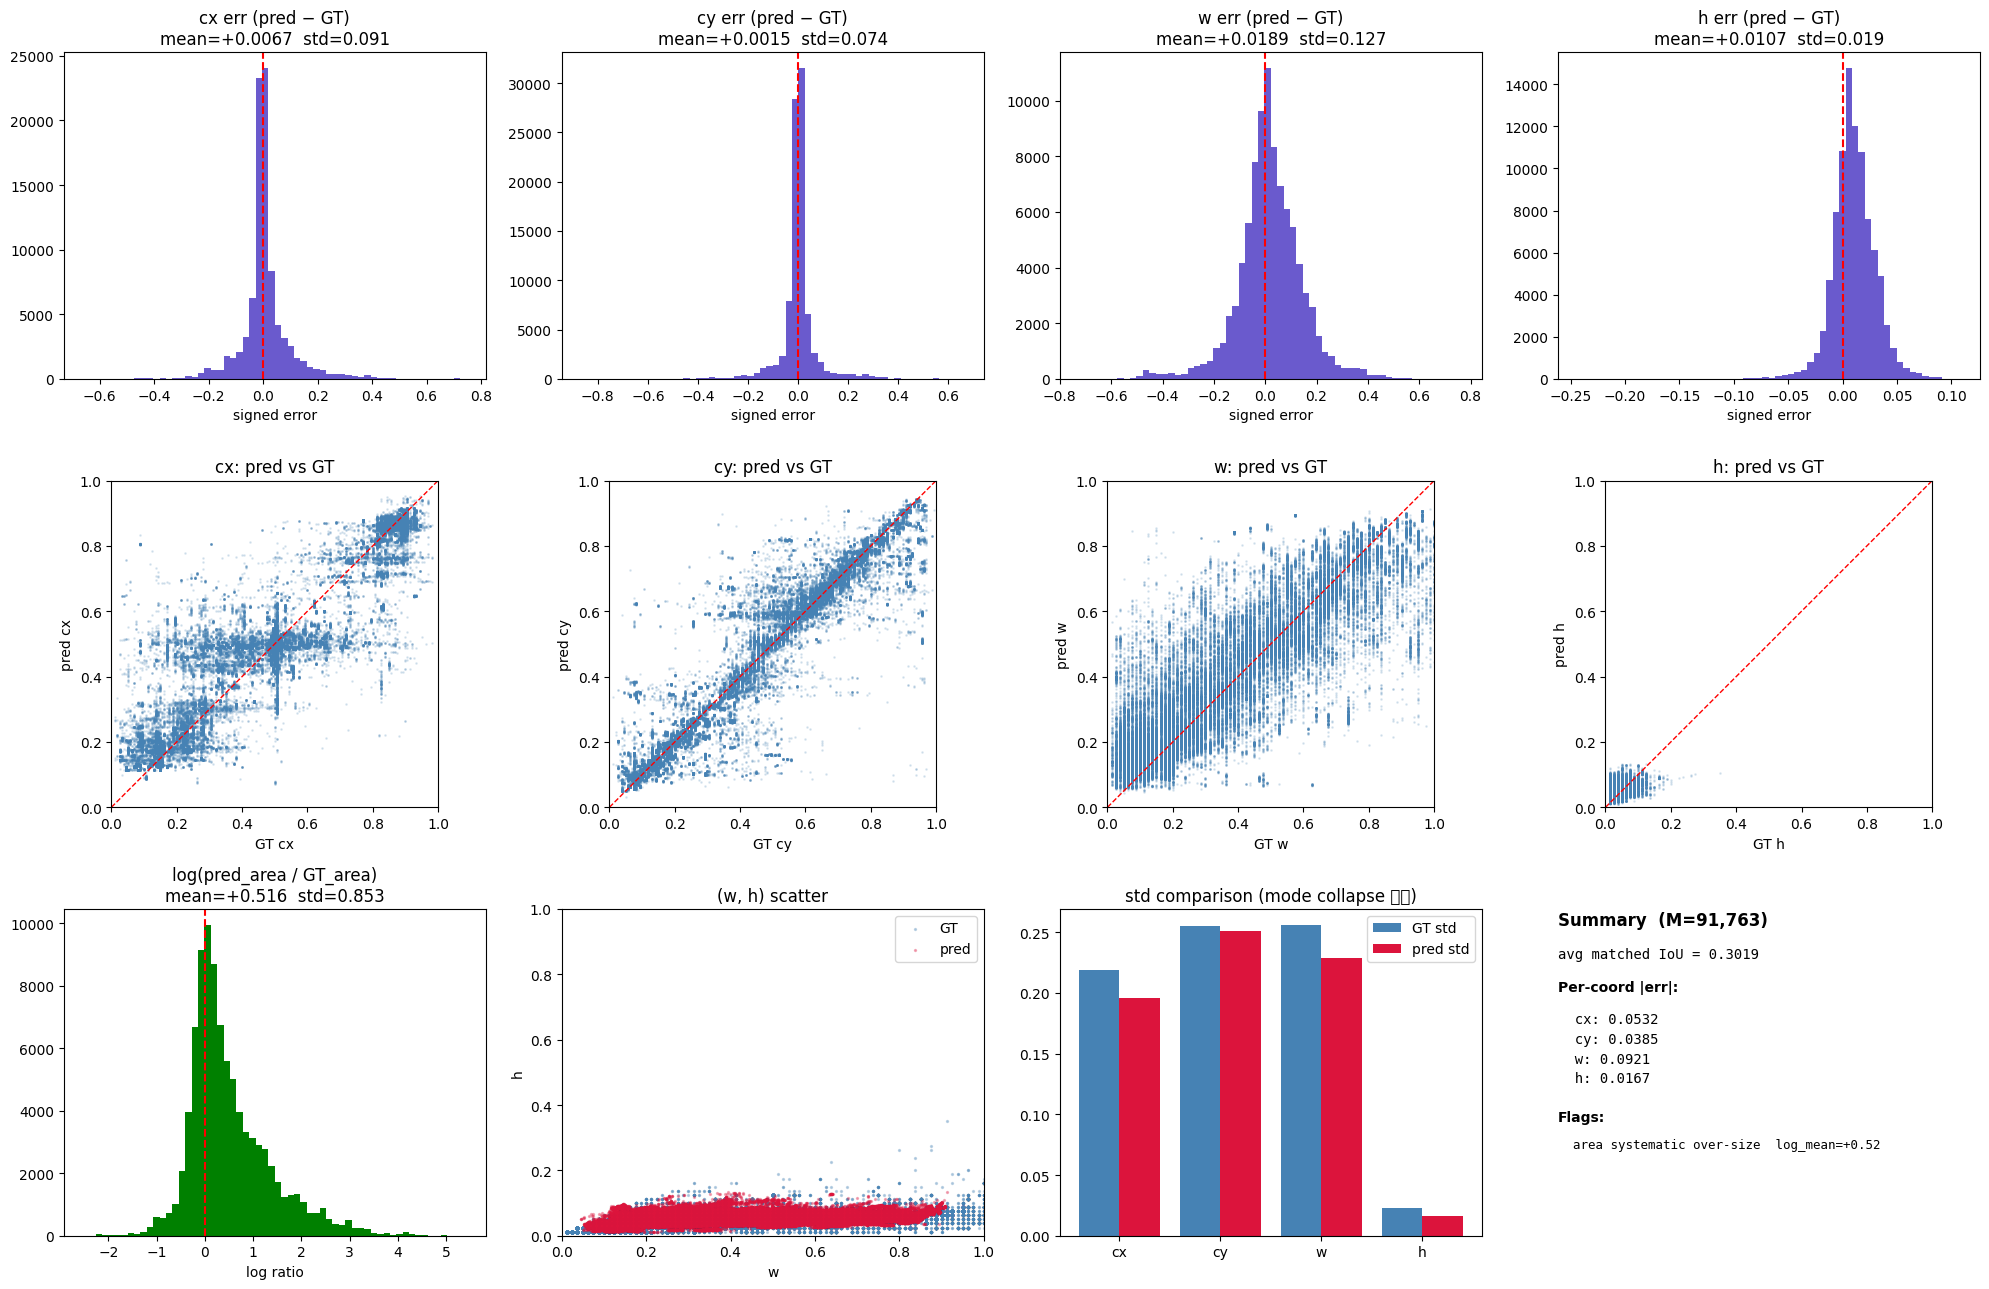

In [3]:
# %% 셀 3: 진단 — Hungarian-matched pred ↔ GT pair에서 per-coord 오차 + area ratio + std 비교
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

OBJ_THRESH = 0.5
USE_BF16 = (device.type == "cuda")
COST_CLASS, COST_BBOX, COST_GIOU = 1.0, 5.0, 2.0


def cxcywh_to_xyxy_np(b):
    cx, cy, w, h = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], axis=-1)


def giou_np(b1, b2):
    """b1: (N,4) xyxy, b2: (M,4) xyxy → giou (N,M), iou (N,M)"""
    a1 = (b1[:, 2] - b1[:, 0]).clip(0) * (b1[:, 3] - b1[:, 1]).clip(0)
    a2 = (b2[:, 2] - b2[:, 0]).clip(0) * (b2[:, 3] - b2[:, 1]).clip(0)
    lt = np.maximum(b1[:, None, :2], b2[None, :, :2])
    rb = np.minimum(b1[:, None, 2:], b2[None, :, 2:])
    wh = (rb - lt).clip(0)
    inter = wh[..., 0] * wh[..., 1]
    union = a1[:, None] + a2[None, :] - inter
    iou = inter / np.maximum(union, 1e-7)
    lt_e = np.minimum(b1[:, None, :2], b2[None, :, :2])
    rb_e = np.maximum(b1[:, None, 2:], b2[None, :, 2:])
    wh_e = (rb_e - lt_e).clip(0)
    enc = wh_e[..., 0] * wh_e[..., 1]
    giou = iou - (enc - union) / np.maximum(enc, 1e-7)
    return giou, iou


# ── inference + matched pair 수집 (segment chunking으로 OOM 방지) ──
SEG_CHUNK = 128

matched_pred, matched_gt, matched_iou_list = [], [], []
all_prob = []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="diagnose"):
        batch = {k: (v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v)
                 for k, v in batch.items()}
        with torch.amp.autocast('cuda', dtype=torch.bfloat16, enabled=USE_BF16):
            inst_tokens, _ = model.encode_inst(
                batch["channel_ids"],
                batch["inst_diff_ch"], batch["inst_diff_vid"], batch["inst_diff_stt"],
                batch["inst_scalars"])

        S_total = batch["seg_video_idx"].shape[0]
        gt_np_full = batch["seg_gt_boxes"].cpu().numpy()
        gtm_np_full = batch["seg_gt_box_mask"].cpu().numpy()

        for s_start in range(0, S_total, SEG_CHUNK):
            s_end = min(s_start + SEG_CHUNK, S_total)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16, enabled=USE_BF16):
                pb, pl = model.predict_segments(
                    inst_tokens, batch["channel_ids"],
                    batch["seg_active_mask"][s_start:s_end],
                    batch["seg_merged_mask"][s_start:s_end],
                    batch["seg_time_feats"][s_start:s_end],
                    batch["seg_video_idx"][s_start:s_end])

            prob = F.softmax(pl.float(), dim=-1)[..., 0]
            pb_np = pb.float().cpu().numpy()
            prob_np = prob.cpu().numpy()
            gt_np = gt_np_full[s_start:s_end]
            gtm_np = gtm_np_full[s_start:s_end]
            all_prob.append(prob_np.reshape(-1))

            S = pb_np.shape[0]
            for s in range(S):
                valid_g = np.where(gtm_np[s])[0]
                if len(valid_g) == 0:
                    continue
                pb_s = pb_np[s]                     # (Q, 4)
                gt_s = gt_np[s, valid_g]            # (K, 4)
                # cost: class+box+giou (training matching과 동일)
                box_cost = np.abs(pb_s[:, None, :] - gt_s[None, :, :]).sum(-1)   # (Q, K)
                pb_xy = cxcywh_to_xyxy_np(pb_s)
                gt_xy = cxcywh_to_xyxy_np(gt_s)
                giou, iou = giou_np(pb_xy, gt_xy)                                # (Q, K)
                class_cost = -prob_np[s][:, None]                                # (Q, 1)
                cost = COST_CLASS * class_cost + COST_BBOX * box_cost - COST_GIOU * giou
                p_idx, g_local = linear_sum_assignment(cost)
                matched_pred.append(pb_s[p_idx])
                matched_gt.append(gt_s[g_local])
                matched_iou_list.append(iou[p_idx, g_local])

            del pb, pl, prob, pb_np, prob_np

matched_pred = np.concatenate(matched_pred)         # (M, 4)
matched_gt   = np.concatenate(matched_gt)           # (M, 4)
matched_iou  = np.concatenate(matched_iou_list)     # (M,)
all_prob     = np.concatenate(all_prob)
M = len(matched_pred)

# ── 통계 ────────────────────────────────────────────────────────────
err = matched_pred - matched_gt                     # signed
abs_err = np.abs(err)
labels = ['cx', 'cy', 'w', 'h']

print(f"matched pairs M = {M:,}    avg matched IoU = {matched_iou.mean():.4f}")
print(f"\n[per-coord 오차]  (pred - GT)")
print(f"{'coord':<6}{'|err| mean':>12}{'signed mean':>14}{'err std':>10}{'GT std':>10}{'pred std':>11}{'ratio(pred/GT std)':>22}")
for i, lab in enumerate(labels):
    gs = matched_gt[:, i].std()
    ps = matched_pred[:, i].std()
    print(f"{lab:<6}{abs_err[:,i].mean():>12.4f}{err[:,i].mean():>+14.4f}"
          f"{err[:,i].std():>10.4f}{gs:>10.4f}{ps:>11.4f}{ps/max(gs,1e-6):>22.3f}")

pred_area = matched_pred[:, 2] * matched_pred[:, 3]
gt_area   = matched_gt[:, 2] * matched_gt[:, 3]
log_ratio = np.log(np.maximum(pred_area, 1e-8) / np.maximum(gt_area, 1e-8))
print(f"\n[area ratio]  log(pred_area / GT_area)")
print(f"  mean={log_ratio.mean():+.3f}  median={np.median(log_ratio):+.3f}  std={log_ratio.std():.3f}")
print(f"  pred_area mean={pred_area.mean():.5f}  GT_area mean={gt_area.mean():.5f}  "
      f"linear ratio={pred_area.mean()/max(gt_area.mean(),1e-8):.3f}")

# ── 시각화 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 13))

# Row 0: signed error histogram per coord (편향 방향)
for i, lab in enumerate(labels):
    axes[0, i].hist(err[:, i], bins=60, color='slateblue')
    axes[0, i].axvline(0, color='red', linestyle='--')
    axes[0, i].set_title(f'{lab} err (pred − GT)\nmean={err[:,i].mean():+.4f}  std={err[:,i].std():.3f}')
    axes[0, i].set_xlabel('signed error')

# Row 1: GT vs pred scatter per coord (대각선 = perfect)
for i, lab in enumerate(labels):
    axes[1, i].scatter(matched_gt[:, i], matched_pred[:, i], s=1, alpha=0.15, color='steelblue')
    axes[1, i].plot([0, 1], [0, 1], 'r--', linewidth=1)
    axes[1, i].set_xlim(0, 1); axes[1, i].set_ylim(0, 1)
    axes[1, i].set_aspect('equal')
    axes[1, i].set_xlabel(f'GT {lab}'); axes[1, i].set_ylabel(f'pred {lab}')
    axes[1, i].set_title(f'{lab}: pred vs GT')

# Row 2: log area ratio + (w,h) scatter + std bar + summary text
axes[2, 0].hist(log_ratio, bins=60, color='green')
axes[2, 0].axvline(0, color='red', linestyle='--')
axes[2, 0].set_title(f'log(pred_area / GT_area)\nmean={log_ratio.mean():+.3f}  std={log_ratio.std():.3f}')
axes[2, 0].set_xlabel('log ratio')

axes[2, 1].scatter(matched_gt[:, 2], matched_gt[:, 3], s=2, alpha=0.3, color='steelblue', label='GT')
axes[2, 1].scatter(matched_pred[:, 2], matched_pred[:, 3], s=2, alpha=0.3, color='crimson', label='pred')
axes[2, 1].set_xlim(0, 1); axes[2, 1].set_ylim(0, 1)
axes[2, 1].set_xlabel('w'); axes[2, 1].set_ylabel('h')
axes[2, 1].legend()
axes[2, 1].set_title('(w, h) scatter')

# pred std / GT std bar — mode collapse 여부
gt_stds = [matched_gt[:, i].std() for i in range(4)]
pred_stds = [matched_pred[:, i].std() for i in range(4)]
xpos = np.arange(4)
axes[2, 2].bar(xpos - 0.2, gt_stds, 0.4, label='GT std', color='steelblue')
axes[2, 2].bar(xpos + 0.2, pred_stds, 0.4, label='pred std', color='crimson')
axes[2, 2].set_xticks(xpos); axes[2, 2].set_xticklabels(labels)
axes[2, 2].set_title('std comparison (mode collapse 체크)')
axes[2, 2].legend()

# Summary text + 처방 hint
axes[2, 3].axis('off')
hints = []
# bias 방향 진단
for i, lab in enumerate(labels):
    m = err[:, i].mean()
    if abs(m) > 0.02:
        sign = '+' if m > 0 else '-'
        hints.append(f"  {lab} bias {sign}{abs(m):.3f}")
# pred std collapse
for i, lab in enumerate(labels):
    if pred_stds[i] < gt_stds[i] * 0.5:
        hints.append(f"  {lab} std collapse  ({pred_stds[i]:.3f} vs GT {gt_stds[i]:.3f})")
# area
if abs(log_ratio.mean()) > 0.2:
    hints.append(f"  area systematic { 'over' if log_ratio.mean()>0 else 'under' }-size  log_mean={log_ratio.mean():+.2f}")

axes[2, 3].text(0.0, 0.95, f'Summary  (M={M:,})', fontsize=12, fontweight='bold',
                transform=axes[2, 3].transAxes)
axes[2, 3].text(0.0, 0.85, f'avg matched IoU = {matched_iou.mean():.4f}',
                transform=axes[2, 3].transAxes, family='monospace')
axes[2, 3].text(0.0, 0.75, 'Per-coord |err|:', fontsize=10, fontweight='bold',
                transform=axes[2, 3].transAxes)
for j, lab in enumerate(labels):
    axes[2, 3].text(0.0, 0.65 - j * 0.06,
                    f'  {lab}: {abs_err[:,j].mean():.4f}',
                    transform=axes[2, 3].transAxes, family='monospace')
axes[2, 3].text(0.0, 0.35, 'Flags:', fontsize=10, fontweight='bold',
                transform=axes[2, 3].transAxes)
if hints:
    for j, h in enumerate(hints[:6]):
        axes[2, 3].text(0.0, 0.27 - j * 0.06, h,
                        transform=axes[2, 3].transAxes, family='monospace', fontsize=9)
else:
    axes[2, 3].text(0.0, 0.27, '  (no strong bias / collapse detected)',
                    transform=axes[2, 3].transAxes, family='monospace', fontsize=9)

plt.tight_layout()
plt.show()
